In [2]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import os
import pandas as pd
import matplotlib.pyplot as plt

# Consistent colors across all notebooks
colors = {
    "GA-only": "blue",
    "GA+Rules": "red",
    "GA+Surrogate": "orange",
    "Hybrid": "green",
}

method_names = {
    "ga_only": "GA-only",
    "ga_rules": "GA+Rules",
    "ga_surrogate": "GA+Surrogate",
    "hybrid": "Hybrid",
}

method_order = ["GA-only", "GA+Rules", "GA+Surrogate", "Hybrid"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Research/glycemic-hybrid-ga


In [3]:
# CELL 2 — Load convergence summary
summary_path = "outputs/results/summary_all.csv"

df = pd.read_csv(summary_path)
df["MethodLabel"] = df["Method"].map(method_names)

df

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,StdG,CV,SevereHypo,SimCalls,DatasetSize,AUCsum,AUCmean,AUCregret,MethodLabel
0,S1_normal,ga_only,99.374014,99.374014,100.000000,0.0,0.000000,92.877338,135.875743,110.822083,8.116355,7.323771,0,2400,-1,5954.712182,99.245203,9.581747,GA-only
1,S1_normal,ga_rules,99.178881,99.178881,100.000000,0.0,0.000000,79.786971,139.775824,109.860057,11.720615,10.668678,0,2400,-1,5948.500595,99.141677,15.793334,GA+Rules
2,S1_normal,ga_surrogate,99.404899,99.404899,100.000000,0.0,0.000000,88.296957,133.896006,110.213543,8.368179,7.592696,0,1752,1752,5952.006190,99.200103,12.287739,GA+Surrogate
3,S1_normal,hybrid,99.222139,99.222139,100.000000,0.0,0.000000,80.164327,125.770374,107.744512,8.623141,8.003323,0,1752,1752,5952.268221,99.204470,12.025708,Hybrid
4,S2_ramadan,ga_only,98.904381,98.904381,100.000000,0.0,0.000000,71.724759,159.434062,108.942920,14.614990,13.415273,0,2400,-1,5926.712623,98.778544,13.568054,GA-only
5,S2_ramadan,ga_rules,98.987936,98.987936,100.000000,0.0,0.000000,78.757416,165.565792,110.463753,14.119118,12.781675,0,2400,-1,5933.711249,98.895187,6.569429,GA+Rules
6,S2_ramadan,ga_surrogate,98.939039,98.939039,100.000000,0.0,0.000000,86.148628,140.131364,114.400953,10.312367,9.014232,0,1752,1752,5936.342366,98.939039,3.938312,GA+Surrogate
7,S2_ramadan,hybrid,99.004678,99.004678,100.000000,0.0,0.000000,77.622338,149.973937,110.375584,13.977348,12.663442,0,1752,1752,5924.634781,98.743913,15.645896,Hybrid
8,S3_stress_highcarb,ga_only,98.221204,98.221204,100.000000,0.0,0.000000,74.033752,152.682695,117.110293,17.653788,15.074498,0,2400,-1,5721.150903,95.352515,201.736015,GA-only
9,S3_stress_highcarb,ga_rules,98.714782,98.714782,100.000000,0.0,0.000000,71.230041,143.352138,108.135026,16.405168,15.171003,0,2400,-1,5509.498811,91.824980,413.388107,GA+Rules


In [4]:
# CELL 3 - Check data

print("Scenarios:", df["Scenario"].unique())
print("Methods:", df["MethodLabel"].unique())

df[["Scenario", "MethodLabel", "BestTrueFitness", "AUCmean", "AUCregret", "SimCalls"]]

Scenarios: ['S1_normal' 'S2_ramadan' 'S3_stress_highcarb' 'S4_exercise_lowcarb']
Methods: ['GA-only' 'GA+Rules' 'GA+Surrogate' 'Hybrid']


,Scenario,MethodLabel,BestTrueFitness,AUCmean,AUCregret,SimCalls
0,S1_normal,GA-only,99.374014,99.245203,9.581747,2400
1,S1_normal,GA+Rules,99.178881,99.141677,15.793334,2400
2,S1_normal,GA+Surrogate,99.404899,99.200103,12.287739,1752
3,S1_normal,Hybrid,99.222139,99.204470,12.025708,1752
4,S2_ramadan,GA-only,98.904381,98.778544,13.568054,2400
5,S2_ramadan,GA+Rules,98.987936,98.895187,6.569429,2400
6,S2_ramadan,GA+Surrogate,98.939039,98.939039,3.938312,1752
7,S2_ramadan,Hybrid,99.004678,98.743913,15.645896,1752
8,S3_stress_highcarb,GA-only,98.221204,95.352515,201.736015,2400
9,S3_stress_highcarb,GA+Rules,98.714782,91.824980,413.388107,2400


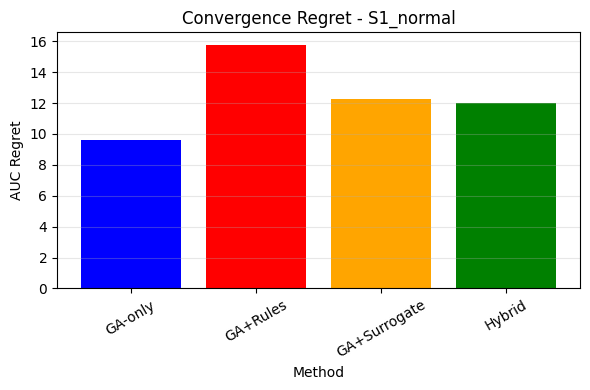

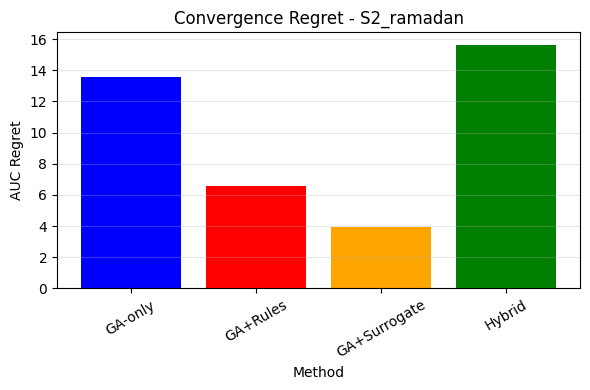

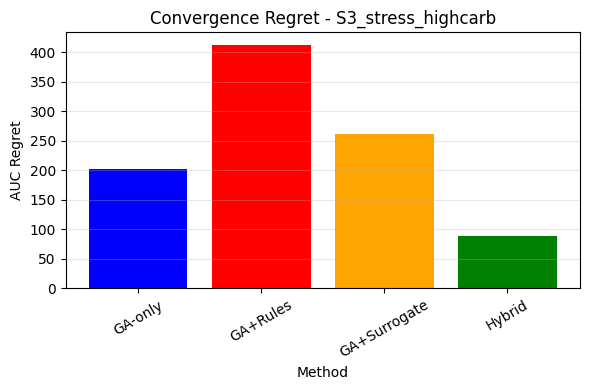

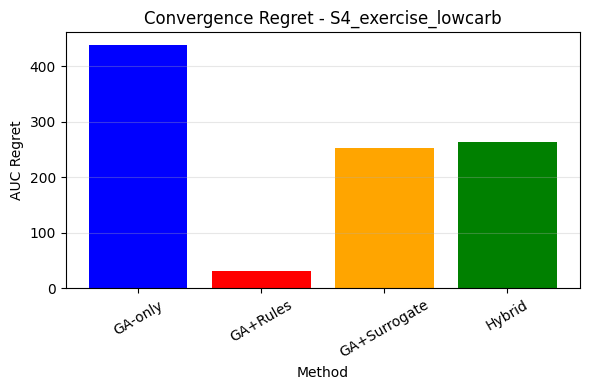

In [5]:
#CELL 4 — Convergence regret figures
for scenario in df["Scenario"].unique():
    subset = df[df["Scenario"] == scenario].copy()

    subset["MethodLabel"] = pd.Categorical(
        subset["MethodLabel"],
        categories=method_order,
        ordered=True
    )
    subset = subset.sort_values("MethodLabel")

    methods = subset["MethodLabel"].tolist()
    values = subset["AUCregret"].tolist()

    plt.figure(figsize=(6,4))
    plt.bar(
        methods,
        values,
        color=[colors[m] for m in methods]
    )

    plt.title(f"Convergence Regret - {scenario}")
    plt.ylabel("AUC Regret")
    plt.xlabel("Method")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
#CELL 5 — Save convergence regret figures
os.makedirs("figures", exist_ok=True)

for scenario in df["Scenario"].unique():
    subset = df[df["Scenario"] == scenario].copy()

    subset["MethodLabel"] = pd.Categorical(
        subset["MethodLabel"],
        categories=method_order,
        ordered=True
    )
    subset = subset.sort_values("MethodLabel")

    methods = subset["MethodLabel"].tolist()
    values = subset["AUCregret"].tolist()

    plt.figure(figsize=(6,4))
    plt.bar(
        methods,
        values,
        color=[colors[m] for m in methods]
    )

    plt.title(f"Convergence Regret - {scenario}")
    plt.ylabel("AUC Regret")
    plt.xlabel("Method")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()

    out = f"figures/regret_{scenario}.pdf"
    plt.savefig(out, bbox_inches="tight")
    plt.close()

    print("Saved:", out)

Saved: figures/regret_S1_normal.pdf
Saved: figures/regret_S2_ramadan.pdf
Saved: figures/regret_S3_stress_highcarb.pdf
Saved: figures/regret_S4_exercise_lowcarb.pdf


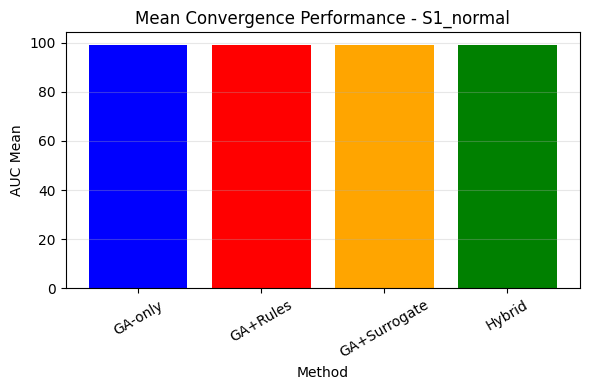

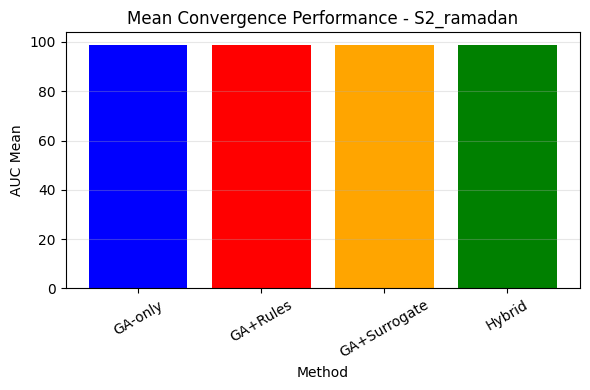

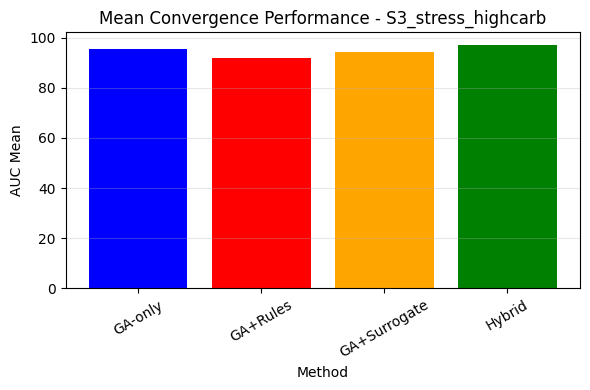

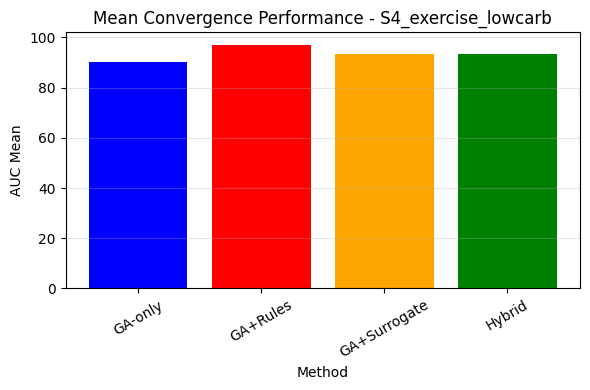

In [7]:
#CELL 6 — AUC mean figures
for scenario in df["Scenario"].unique():
    subset = df[df["Scenario"] == scenario].copy()

    subset["MethodLabel"] = pd.Categorical(
        subset["MethodLabel"],
        categories=method_order,
        ordered=True
    )
    subset = subset.sort_values("MethodLabel")

    methods = subset["MethodLabel"].tolist()
    values = subset["AUCmean"].tolist()

    plt.figure(figsize=(6,4))
    plt.bar(
        methods,
        values,
        color=[colors[m] for m in methods]
    )

    plt.title(f"Mean Convergence Performance - {scenario}")
    plt.ylabel("AUC Mean")
    plt.xlabel("Method")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
#CELL 7 — Simulation calls
cost = df[["Scenario", "MethodLabel", "SimCalls"]].copy()
cost

,Scenario,MethodLabel,SimCalls
0,S1_normal,GA-only,2400
1,S1_normal,GA+Rules,2400
2,S1_normal,GA+Surrogate,1752
3,S1_normal,Hybrid,1752
4,S2_ramadan,GA-only,2400
5,S2_ramadan,GA+Rules,2400
6,S2_ramadan,GA+Surrogate,1752
7,S2_ramadan,Hybrid,1752
8,S3_stress_highcarb,GA-only,2400
9,S3_stress_highcarb,GA+Rules,2400


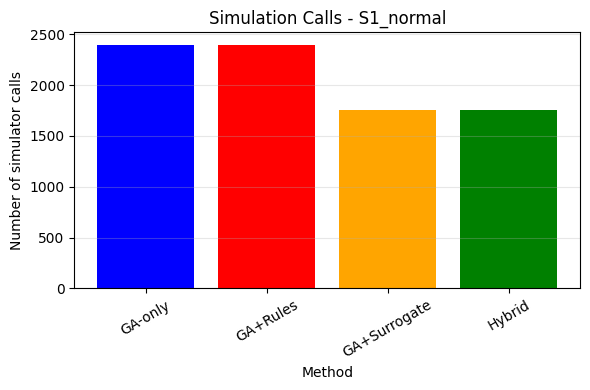

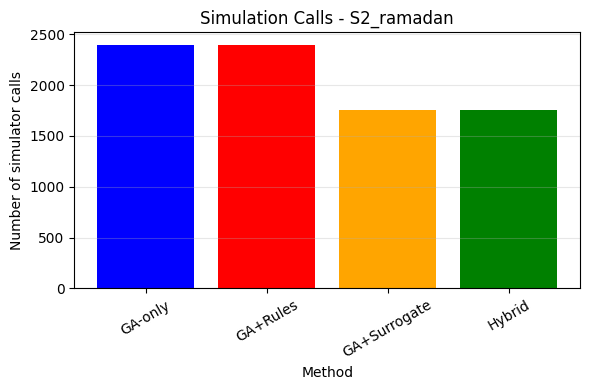

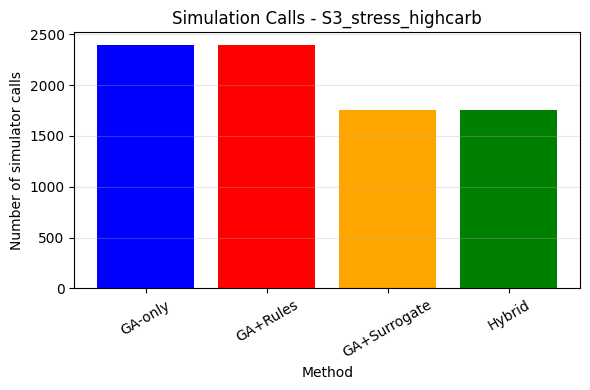

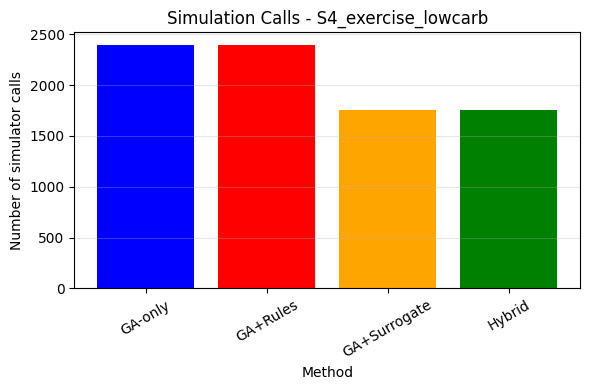

In [9]:
# CELL 8 — Simulation calls per scenario
for scenario in df["Scenario"].unique():
    subset = df[df["Scenario"] == scenario].copy()

    subset["MethodLabel"] = pd.Categorical(
        subset["MethodLabel"],
        categories=method_order,
        ordered=True
    )
    subset = subset.sort_values("MethodLabel")

    methods = subset["MethodLabel"].tolist()
    values = subset["SimCalls"].tolist()

    plt.figure(figsize=(6,4))
    plt.bar(
        methods,
        values,
        color=[colors[m] for m in methods]
    )

    plt.title(f"Simulation Calls - {scenario}")
    plt.ylabel("Number of simulator calls")
    plt.xlabel("Method")
    plt.xticks(rotation=30)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

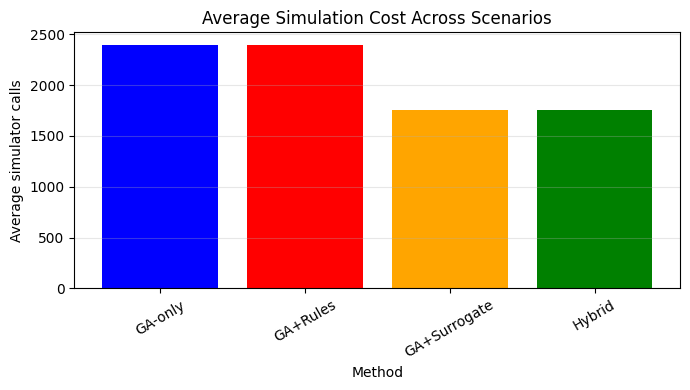

Saved: figures/simulation_cost_average.pdf


In [10]:
#CELL 9 — Average simulation cost figure
avg_cost = df.groupby("MethodLabel", as_index=False)["SimCalls"].mean()

avg_cost["MethodLabel"] = pd.Categorical(
    avg_cost["MethodLabel"],
    categories=method_order,
    ordered=True
)
avg_cost = avg_cost.sort_values("MethodLabel")

methods = avg_cost["MethodLabel"].tolist()
values = avg_cost["SimCalls"].tolist()

plt.figure(figsize=(7,4))
plt.bar(
    methods,
    values,
    color=[colors[m] for m in methods]
)

plt.title("Average Simulation Cost Across Scenarios")
plt.ylabel("Average simulator calls")
plt.xlabel("Method")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

out = "figures/simulation_cost_average.pdf"
plt.savefig(out, bbox_inches="tight")
plt.show()

print("Saved:", out)

In [11]:
#CELL 10 — Reduction percentage
ga_cost = df[df["Method"] == "ga_only"]["SimCalls"].mean()
hybrid_cost = df[df["Method"] == "hybrid"]["SimCalls"].mean()

reduction = (ga_cost - hybrid_cost) / ga_cost * 100

print("GA-only average calls:", ga_cost)
print("Hybrid average calls:", hybrid_cost)
print("Reduction (%):", reduction)

GA-only average calls: 2400.0
Hybrid average calls: 1752.0
Reduction (%): 27.0


In [12]:
# CELL 11 — Convergence table for paper
conv_table = df[[
    "Scenario",
    "MethodLabel",
    "BestTrueFitness",
    "AUCmean",
    "AUCregret",
    "SimCalls"
]].copy()

conv_table["MethodLabel"] = pd.Categorical(
    conv_table["MethodLabel"],
    categories=method_order,
    ordered=True
)

conv_table = conv_table.sort_values(["Scenario", "MethodLabel"])
conv_table

,Scenario,MethodLabel,BestTrueFitness,AUCmean,AUCregret,SimCalls
0,S1_normal,GA-only,99.374014,99.245203,9.581747,2400
1,S1_normal,GA+Rules,99.178881,99.141677,15.793334,2400
2,S1_normal,GA+Surrogate,99.404899,99.200103,12.287739,1752
3,S1_normal,Hybrid,99.222139,99.204470,12.025708,1752
4,S2_ramadan,GA-only,98.904381,98.778544,13.568054,2400
5,S2_ramadan,GA+Rules,98.987936,98.895187,6.569429,2400
6,S2_ramadan,GA+Surrogate,98.939039,98.939039,3.938312,1752
7,S2_ramadan,Hybrid,99.004678,98.743913,15.645896,1752
8,S3_stress_highcarb,GA-only,98.221204,95.352515,201.736015,2400
9,S3_stress_highcarb,GA+Rules,98.714782,91.824980,413.388107,2400


In [13]:
#CELL 12 — Export LaTeX table
latex = conv_table.to_latex(
    index=False,
    float_format="%.2f",
    caption="Convergence and computational cost comparison.",
    label="tab:convergence_cost"
)

print(latex)

\begin{table}
\caption{Convergence and computational cost comparison.}
\label{tab:convergence_cost}
\begin{tabular}{llrrrr}
\toprule
Scenario & MethodLabel & BestTrueFitness & AUCmean & AUCregret & SimCalls \\
\midrule
S1_normal & GA-only & 99.37 & 99.25 & 9.58 & 2400 \\
S1_normal & GA+Rules & 99.18 & 99.14 & 15.79 & 2400 \\
S1_normal & GA+Surrogate & 99.40 & 99.20 & 12.29 & 1752 \\
S1_normal & Hybrid & 99.22 & 99.20 & 12.03 & 1752 \\
S2_ramadan & GA-only & 98.90 & 98.78 & 13.57 & 2400 \\
S2_ramadan & GA+Rules & 98.99 & 98.90 & 6.57 & 2400 \\
S2_ramadan & GA+Surrogate & 98.94 & 98.94 & 3.94 & 1752 \\
S2_ramadan & Hybrid & 99.00 & 98.74 & 15.65 & 1752 \\
S3_stress_highcarb & GA-only & 98.22 & 95.35 & 201.74 & 2400 \\
S3_stress_highcarb & GA+Rules & 98.71 & 91.82 & 413.39 & 2400 \\
S3_stress_highcarb & GA+Surrogate & 97.66 & 94.35 & 261.82 & 1752 \\
S3_stress_highcarb & Hybrid & 98.28 & 97.24 & 88.38 & 1752 \\
S4_exercise_lowcarb & GA-only & 97.60 & 90.36 & 438.78 & 2400 \\
S4_exercise_l

In [14]:
# CELL 12 — Export LaTeX
latex = conv_table.to_latex(
    index=False,
    float_format="%.2f",
    caption="Convergence and computational cost comparison.",
    label="tab:convergence_cost"
)

print(latex)

\begin{table}
\caption{Convergence and computational cost comparison.}
\label{tab:convergence_cost}
\begin{tabular}{llrrrr}
\toprule
Scenario & MethodLabel & BestTrueFitness & AUCmean & AUCregret & SimCalls \\
\midrule
S1_normal & GA-only & 99.37 & 99.25 & 9.58 & 2400 \\
S1_normal & GA+Rules & 99.18 & 99.14 & 15.79 & 2400 \\
S1_normal & GA+Surrogate & 99.40 & 99.20 & 12.29 & 1752 \\
S1_normal & Hybrid & 99.22 & 99.20 & 12.03 & 1752 \\
S2_ramadan & GA-only & 98.90 & 98.78 & 13.57 & 2400 \\
S2_ramadan & GA+Rules & 98.99 & 98.90 & 6.57 & 2400 \\
S2_ramadan & GA+Surrogate & 98.94 & 98.94 & 3.94 & 1752 \\
S2_ramadan & Hybrid & 99.00 & 98.74 & 15.65 & 1752 \\
S3_stress_highcarb & GA-only & 98.22 & 95.35 & 201.74 & 2400 \\
S3_stress_highcarb & GA+Rules & 98.71 & 91.82 & 413.39 & 2400 \\
S3_stress_highcarb & GA+Surrogate & 97.66 & 94.35 & 261.82 & 1752 \\
S3_stress_highcarb & Hybrid & 98.28 & 97.24 & 88.38 & 1752 \\
S4_exercise_lowcarb & GA-only & 97.60 & 90.36 & 438.78 & 2400 \\
S4_exercise_l